In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Environment works.")

Environment works.


# Day 1: First Market Data Download

We download daily price data for SPY and AAPL, inspect the dataset, and prepare for return calculations.

In [2]:
import yfinance as yf
import pandas as pd

tickers = ["SPY", "AAPL"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                   High                    Low  \
Ticker           AAPL         SPY       AAPL         SPY       AAPL   
Date                                                                  
2020-01-02  72.400497  296.888214  72.460761  296.906509  71.156659   
2020-01-03  71.696655  294.640045  72.455974  295.764112  71.472477   
2020-01-06  72.267921  295.764221  72.306491  295.846466  70.568495   
2020-01-07  71.928070  294.932587  72.533110  295.672817  71.708710   
2020-01-08  73.085114  296.504425  73.386431  297.719857  71.631559   

Price                        Open                 Volume            
Ticker             SPY       AAPL         SPY       AAPL       SPY  
Date                                                                
2020-01-02  294.749767  71.409763  295.672782  135480400  59151200  
2020-01-03  293.442881  71.629160  293.497711  146322800  77709700  
2020-01-06  292.766708  70.819193  292.885515  118387200  55653900  
2020-01-07  294.484772  72.277594  295.197588  108872000  40496400  
2020-01-08  294.877741  71.631559  295.124476  132079200  68296000

In [7]:
# Check the column structure
data.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close',  'SPY'),
            (  'High', 'AAPL'),
            (  'High',  'SPY'),
            (   'Low', 'AAPL'),
            (   'Low',  'SPY'),
            (  'Open', 'AAPL'),
            (  'Open',  'SPY'),
            ('Volume', 'AAPL'),
            ('Volume',  'SPY')],
           names=['Price', 'Ticker'])

In [8]:
# Check shape and missing values
print("Shape of raw data:", data.shape)
print("\nMissing values by column:")
print(data.isna().sum())

Shape of raw data: (1508, 10)

Missing values by column:
Price   Ticker
Close   AAPL      0
        SPY       0
High    AAPL      0
        SPY       0
Low     AAPL      0
        SPY       0
Open    AAPL      0
        SPY       0
Volume  AAPL      0
        SPY       0
dtype: int64


In [9]:
# Keep only close prices
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,SPY
Date,,
2020-01-02,72.400497,296.888214
2020-01-03,71.696655,294.640045
2020-01-06,72.267921,295.764221
2020-01-07,71.928070,294.932587
2020-01-08,73.085114,296.504425


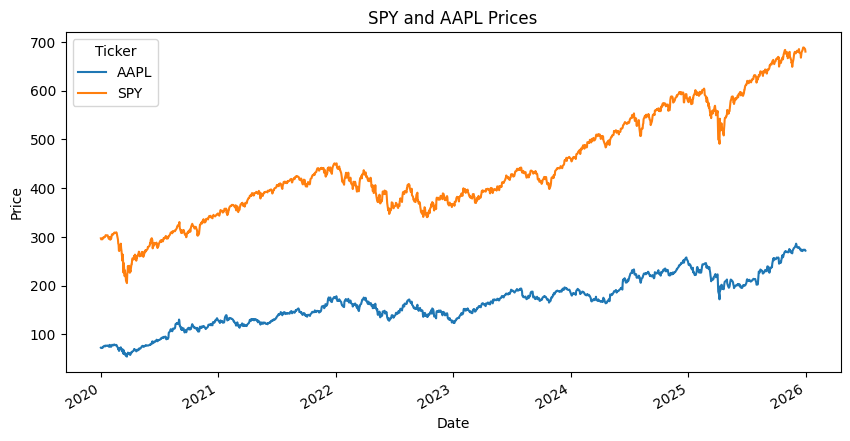

In [10]:
# Plot price series
close_prices.plot(figsize=(10, 5), title="SPY and AAPL Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [11]:
# Save close prices
close_prices.to_csv("../data/day1_close_prices.csv")

In [12]:
# Compute daily simple returns
returns = close_prices.pct_change()
returns.head()

Ticker,AAPL,SPY
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,-0.007572
2020-01-06,0.007968,0.003815
2020-01-07,-0.004703,-0.002812
2020-01-08,0.016086,0.005329


In [13]:
# Drop the first NaN row
returns = returns.dropna()
returns.head()

Ticker,AAPL,SPY
Date,,
2020-01-03,-0.009722,-0.007572
2020-01-06,0.007968,0.003815
2020-01-07,-0.004703,-0.002812
2020-01-08,0.016086,0.005329
2020-01-09,0.021241,0.006781


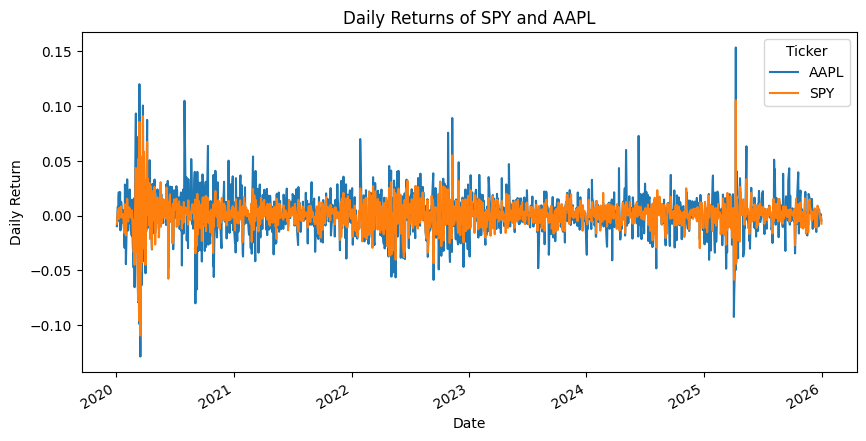

In [14]:
# Plot daily returns
returns.plot(figsize=(10, 5), title="Daily Returns of SPY and AAPL")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

In [15]:
# Summary statistics
returns.describe()

Ticker,AAPL,SPY
count,1507.000000,1507.000000
mean,0.001078,0.000636
std,0.020038,0.013070
min,-0.128647,-0.109424
25%,-0.008209,-0.004845
50%,0.001140,0.000973
75%,0.011464,0.006834
max,0.153288,0.105019


In [16]:
# Mean return and volatility
mean_returns = returns.mean()
volatility = returns.std()

print("Mean daily returns:")
print(mean_returns)
print()
print("Daily volatility:")
print(volatility)

Mean daily returns:
Ticker
AAPL    0.001078
SPY     0.000636
dtype: float64

Daily volatility:
Ticker
AAPL    0.020038
SPY     0.013070
dtype: float64


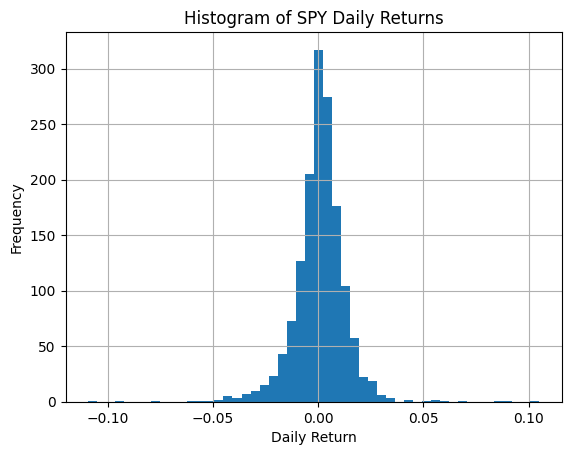

In [17]:
# Histogram for SPY daily returns
returns["SPY"].hist(bins=50)
plt.title("Histogram of SPY Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

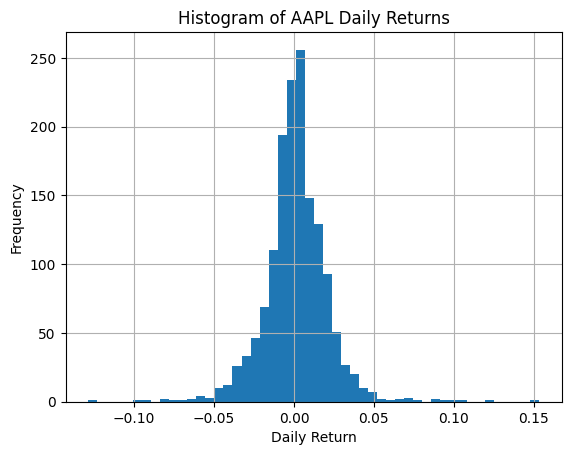

In [18]:
# Histogram for AAPL daily returns
returns["AAPL"].hist(bins=50)
plt.title("Histogram of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Save returns
returns.to_csv("../data/day1_returns.csv")

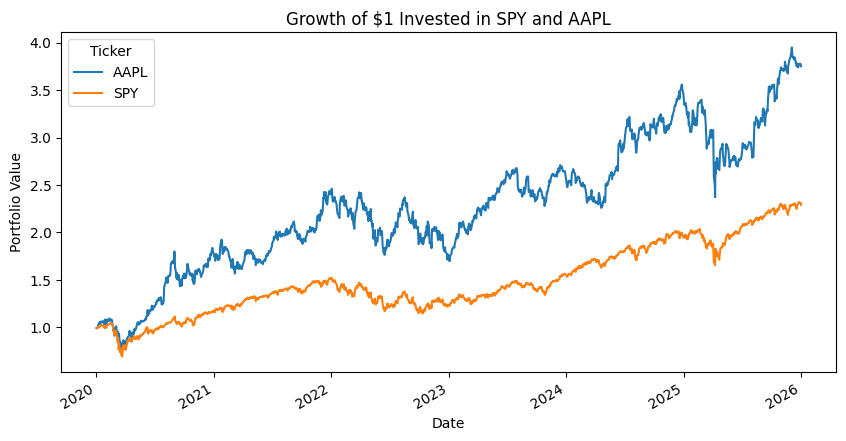

In [20]:
# Optional: compare cumulative growth of $1
cumulative = (1 + returns).cumprod()

cumulative.plot(figsize=(10, 5), title="Growth of $1 Invested in SPY and AAPL")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

In [21]:
# Optional: final quick summary
print("Final summary:")
print("\nLast 5 close prices:")
print(close_prices.tail())

print("\nReturn summary:")
print(returns.describe())

print("\nAnnualized volatility (rough estimate):")
print(returns.std() * np.sqrt(252))

Final summary:

Last 5 close prices:
Ticker            AAPL         SPY
Date                              
2025-12-24  273.554016  688.499695
2025-12-26  273.144409  688.429871
2025-12-29  273.504089  685.976562
2025-12-30  272.824707  685.138916
2025-12-31  271.605835  680.062744

Return summary:
Ticker         AAPL          SPY
count   1507.000000  1507.000000
mean       0.001078     0.000636
std        0.020038     0.013070
min       -0.128647    -0.109424
25%       -0.008209    -0.004845
50%        0.001140     0.000973
75%        0.011464     0.006834
max        0.153288     0.105019

Annualized volatility (rough estimate):
Ticker
AAPL    0.318095
SPY     0.207482
dtype: float64


# Day 1 Report: First Market Data Download and Return Analysis

## Objective

The goal of this notebook is to build the first basic workflow for quantitative finance research in Python.  
In this notebook, I downloaded historical daily market data for SPY and AAPL, inspected the structure of the dataset, extracted closing prices, computed daily returns, and visualized the main patterns in the data.

This is a simple first step, but it is important because most later quantitative research begins with exactly this process: obtaining data, cleaning it, transforming prices into returns, and producing some initial descriptive statistics and plots.

---

## Data Description

I used the `yfinance` package to download daily historical data for two assets:

- **SPY**: an ETF tracking the S\&P 500 index
- **AAPL**: Apple Inc. stock

The sample period in this notebook is from **2020-01-01** to **2026-01-01**.  
The data was downloaded with `auto_adjust=True`, so the price series used in the analysis is adjusted for events such as stock splits and dividends. This makes the series more appropriate for return analysis.

The raw dataset contains multiple fields such as open, high, low, close, and volume.  
For the purpose of this first notebook, I focused only on the **closing price series**.

---

## Inspecting the Raw Data

After downloading the dataset, I first checked the column structure, the shape of the table, and whether there were missing values.

This step is important because in quantitative work, it is not enough to simply load data and assume it is correct.  
A researcher should always inspect:

- what variables are included,
- how the columns are organized,
- whether the date index is correct,
- and whether missing values are present.

From this inspection, I confirmed that the downloaded dataset had the expected structure and that the closing prices could be extracted cleanly for both assets.

---

## Closing Prices

I then extracted the closing price panel for SPY and AAPL and plotted the two price series.

### Observation on prices

From the price plot, both SPY and AAPL show an overall upward trend over the sample period.  
However, the two assets behave differently in terms of smoothness and fluctuation.

SPY appears relatively smoother. This makes sense because SPY is a broad market ETF, so it reflects the performance of a diversified portfolio of large U.S. companies. Diversification tends to reduce the impact of firm-specific shocks.

AAPL, by contrast, shows larger swings. Since AAPL is a single stock, its price is more sensitive to firm-level news, investor sentiment, and company-specific developments. As a result, its path is visibly more volatile than SPY.

This comparison already shows one important idea in finance: a broad index fund and an individual stock may both trend upward over time, but their risk characteristics can be very different.

---

## Why Returns Matter

Although price charts are useful for an initial visual impression, returns are more important than raw prices in quantitative finance.

A price tells us the level of an asset at a point in time.  
A return tells us how much the asset changed relative to the previous period.

In this notebook, I computed **daily simple returns** using:

\[
r_t = \frac{P_t}{P_{t-1}} - 1
\]

where \(P_t\) is the closing price on day \(t\).

The first row of the return series is missing, which is expected, because the first observation has no previous day for comparison.

---

## Daily Return Series

After computing returns, I plotted the daily return series for SPY and AAPL.

### Observation on returns

The return plot looks very different from the price plot.  
Instead of a smooth upward path, the returns fluctuate rapidly around zero.

This is normal in financial data. Prices often contain long-term trend information, while returns capture short-term movement and therefore look much noisier.

Comparing the two assets, AAPL appears to have larger day-to-day fluctuations than SPY. This suggests that AAPL has higher volatility, which is exactly what we would expect from an individual stock compared to a diversified ETF.

This is one of the first important visual lessons in quantitative analysis:

- **price series** often look smooth and persistent,
- **return series** often look noisy and unstable.

Because most risk models, factor models, and backtests are built on returns, understanding this difference is essential.

---

## Summary Statistics

I then computed descriptive statistics for the return series, including:

- mean,
- standard deviation,
- minimum,
- maximum,
- quartiles.

### Observation on summary statistics

The average daily return is small for both assets.  
This is also typical in financial markets: on a day-to-day basis, average returns are usually quite close to zero.

At the same time, the standard deviation is much larger than the mean.  
This shows that daily fluctuations are large relative to the average daily gain. In other words, short-term market noise dominates the average return.

AAPL has a larger standard deviation than SPY, confirming what was already visible from the return plot.  
So from both visual evidence and numerical summary statistics, the conclusion is consistent:

**AAPL is more volatile than SPY over this period.**

This is an important first example of how plots and summary statistics should support each other.

---

## Histograms of Returns

To better understand the distribution of returns, I plotted histograms for the daily returns of SPY and AAPL.

### Observation on return distributions

For both assets, most daily returns are concentrated near zero.  
This means that small daily moves are much more common than large moves.

However, the histograms also show that extreme positive and negative returns do occur.  
This suggests that financial returns are not perfectly stable and that unusually large moves are possible, even if they are relatively rare.

Compared with SPY, the histogram for AAPL is more spread out.  
Again, this reflects higher volatility.

At a conceptual level, this is useful because it shows that returns are not just random noise with identical scale across assets. Different assets can have clearly different distributional shapes and different levels of risk.

---

## Files Created

As part of this workflow, I saved the main outputs as CSV files:

- `day1_close_prices.csv`
- `day1_returns.csv`

This is good practice because it separates:

- **raw or processed data outputs**
- from
- **notebook calculations and plots**

Saving intermediate outputs makes the work easier to reproduce later.

---

## Main Conclusions

This notebook establishes the first basic workflow for quantitative research in Python.

The main conclusions are:

1. Historical market data can be downloaded and handled conveniently using Python.
2. It is important to inspect the raw data structure before analysis.
3. Closing prices are useful for visualization, but returns are the more important object for quantitative analysis.
4. Return series fluctuate around zero and are much noisier than price series.
5. AAPL is more volatile than SPY, both visually and statistically.
6. Histograms show that most daily returns are small, but large moves can still occur.

---

## Reflection

This notebook is simple, but it is a meaningful first step.  
It turns the environment setup into a real research workflow:

- load data,
- inspect data,
- transform data,
- visualize results,
- summarize findings.

This workflow will be the foundation for later topics such as:

- rolling volatility,
- correlations,
- momentum signals,
- backtesting,
- and factor research.

At this stage, the most important thing is not complexity, but clarity.  
The purpose of this notebook is to build a clean and reproducible starting point for more advanced quantitative work later.

---

## Next Step

A natural next step would be to extend this notebook by comparing the two assets further using:

- cumulative returns,
- rolling volatility,
- rolling correlation,
- and simple momentum-style measures.

That would move the analysis from basic descriptive statistics toward the first stage of actual factor-style research.